In [56]:
import sys
sys.path.append('..')

import uproot
import numpy as np
import pandas as pd
import seaborn as sns
import awkward as ak 
import matplotlib.pyplot as plt

from lariat import Event
from matplotlib.patches import Rectangle

In [57]:
allclusters = pd.read_pickle("/Users/user/data/research/proton-deuteron/csv/allclusters.pkl")

In [58]:
allclusters = allclusters[allclusters['height']>1]
allclusters = allclusters[allclusters['column_maxes'].map(lambda x: len(set(x)) > 1)]
collection = (
    (allclusters['plane'] == 'collection') &
    (allclusters['bbox_min_row'] > 12) & (allclusters['bbox_min_row'] < 37) &
    (allclusters['bbox_max_col'] > 789) & (allclusters['bbox_max_col'] < 1927)
)

induction = (
    (allclusters['plane'] == 'induction') &
    (allclusters['bbox_min_row'] > 11) & (allclusters['bbox_min_row'] < 35) &
    (allclusters['bbox_max_col'] > 786) & (allclusters['bbox_max_col'] < 1794)
)

allclusters = allclusters[collection | induction].reset_index(drop=True); print(allclusters.shape)

(34817, 27)


In [59]:
# allclusters[['run', 'subrun', 'event']].drop_duplicates().shape[0]

In [60]:
coll = allclusters[allclusters['plane'] == 'collection']; print(coll.shape)
ind = allclusters[allclusters['plane'] == 'induction']; print(ind.shape)

(16742, 27)
(18075, 27)


In [61]:
coll

,event_idx,run,subrun,event,file_path,event_index,particle_type,plane,cluster_idx,area,...,bbox_min_col,bbox_max_row,bbox_max_col,width,height,aspect_ratio,compactness,image_intensity,matrix_transformed,column_maxes
0,0,8667,148,10828,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,0,9047.0,...,154,196,944,790,171,4.619883,0.066970,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0...","[30.0, 99.0, 109.0, 78.0, 78.0, 80.0, 85.0, 78..."
2,1,8682,479,43081,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,2,10122.0,...,1561,220,1825,264,193,1.367876,0.198658,"[[-0.0, -0.0, -0.0, -0.0, -0.0, 0.0, 0.0, -0.0...","[[-0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0....","[43.0, 53.0, 77.0, 133.0, 66.0, 70.0, 72.0, 71..."
4,3,8599,28,2727,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,0,910.0,...,894,44,1014,120,14,8.571429,0.541667,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-0.0, 18.0, 0.0, -0.0, -0.0, 0.0, -0.0, 0.0,...","[29.0, 400.0, 363.0, 304.0, 308.0, 340.0, 325...."
6,4,8605,447,40174,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,1,6715.0,...,608,138,1051,443,106,4.179245,0.143000,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, -0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -...","[184.0, 183.0, 145.0, 143.0, 143.0, 153.0, 149..."
8,5,9509,427,41399,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,4,10561.0,...,1574,229,1918,344,196,1.755102,0.156636,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, -0.0, 0.0, -0.0, -0.0, -0.0, ...","[33.0, 54.0, 57.0, 57.0, 64.0, 55.0, 58.0, 94...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34808,7632,9788,299,26208,/Users/user/data/research/proton-deuteron/rawp...,0,proton,collection,1,3000.0,...,1095,74,1279,184,53,3.471698,0.307629,"[[-0.0, 0.0, -0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -...","[[16.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, 0.0...","[20.0, 46.0, 90.0, 71.0, 80.0, 98.0, 87.0, 99...."
34810,7633,9788,305,26707,/Users/user/data/research/proton-deuteron/rawp...,0,proton,collection,0,165.0,...,1645,21,1787,142,2,71.000000,0.580986,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 16.0], [0.0, 16.0], [0.0, 17.0], [0.0, ...","[23.0, 60.0]"
34811,7633,9788,305,26707,/Users/user/data/research/proton-deuteron/rawp...,0,proton,collection,1,1079.0,...,883,52,1043,160,20,8.000000,0.337187,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[17.0, -0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -...","[62.0, 115.0, 136.0, 101.0, 99.0, 104.0, 81.0,..."
34813,7634,9788,308,26943,/Users/user/data/research/proton-deuteron/rawp...,0,proton,collection,0,2692.0,...,906,71,1052,146,45,3.244444,0.409741,"[[-0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[[17.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0...","[55.0, 81.0, 87.0, 144.0, 131.0, 120.0, 122.0,..."


In [62]:
ind

,event_idx,run,subrun,event,file_path,event_index,particle_type,plane,cluster_idx,area,...,bbox_min_col,bbox_max_row,bbox_max_col,width,height,aspect_ratio,compactness,image_intensity,matrix_transformed,column_maxes
1,0,8667,148,10828,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,0,4030.0,...,156,169,873,717,148,4.844595,0.037977,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[17.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[20.0, 78.0, 66.0, 55.0, 47.0, 43.0, 47.0, 48...."
3,1,8682,479,43081,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,0,3461.0,...,1617,162,1717,100,142,0.704225,0.243732,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[21.0, 38.0, 80.0, 53.0, 50.0, 46.0, 47.0, 44...."
5,3,8599,28,2727,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,0,530.0,...,856,29,956,100,13,7.692308,0.407692,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[19.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[105.0, 228.0, 205.0, 185.0, 171.0, 168.0, 198..."
7,4,8605,447,40174,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,1,3545.0,...,566,121,958,392,105,3.733333,0.086127,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[49.0, 82.0, 93.0, 90.0, 107.0, 85.0, 95.0, 78..."
11,6,9566,93,8335,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,1,478.0,...,1117,37,1201,84,12,7.000000,0.474206,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[17.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[91.0, 184.0, 175.0, 184.0, 198.0, 195.0, 189...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34807,7631,9788,297,26027,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1550.0,...,755,63,970,215,51,4.215686,0.141359,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[17.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[27.0, 60.0, 71.0, 73.0, 78.0, 75.0, 81.0, 73...."
34809,7632,9788,299,26208,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1456.0,...,1079,76,1222,143,52,2.750000,0.195804,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[24.0, 60.0, 59.0, 58.0, 69.0, 53.0, 52.0, 55...."
34812,7633,9788,305,26707,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,534.0,...,870,33,962,92,20,4.600000,0.290217,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[19.0, 60.0, 70.0, 51.0, 52.0, 54.0, 52.0, 52...."
34814,7634,9788,308,26943,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1359.0,...,891,66,997,106,47,2.255319,0.272782,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[17.0, 50.0, 67.0, 77.0, 68.0, 65.0, 67.0, 73...."


In [63]:
row = allclusters.query('run == 8667 & subrun == 148 & event == 10828')
row

,event_idx,run,subrun,event,file_path,event_index,particle_type,plane,cluster_idx,area,...,bbox_min_col,bbox_max_row,bbox_max_col,width,height,aspect_ratio,compactness,image_intensity,matrix_transformed,column_maxes
0,0,8667,148,10828,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,0,9047.0,...,154,196,944,790,171,4.619883,0.066970,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0...","[30.0, 99.0, 109.0, 78.0, 78.0, 80.0, 85.0, 78..."
1,0,8667,148,10828,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,0,4030.0,...,156,169,873,717,148,4.844595,0.037977,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[17.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[20.0, 78.0, 66.0, 55.0, 47.0, 43.0, 47.0, 48...."


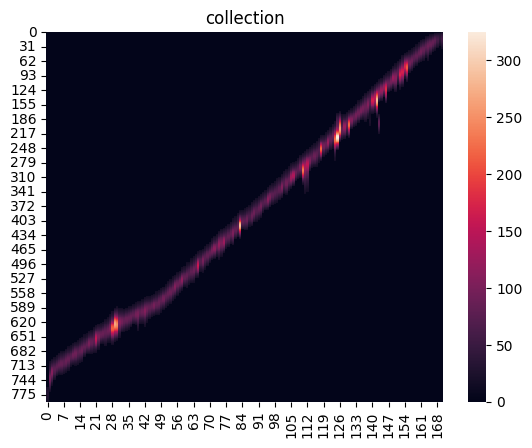

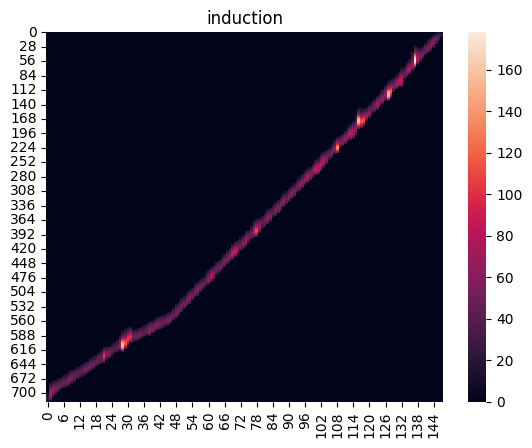

In [64]:
for idx, r in row.iterrows():
    sns.heatmap(r['image_intensity'].T)
    plt.title(f"{r['plane']}")
    plt.show()

In [65]:
c = coll.query('run == 8682 & subrun == 479 & event == 43081')

In [66]:
i = ind.query('run == 8682 & subrun == 479 & event == 43081')

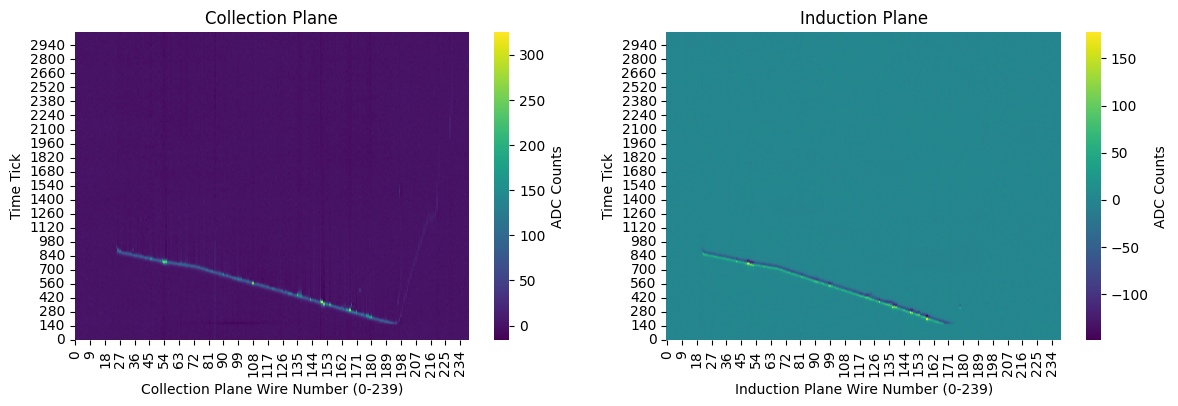

In [67]:
event = Event(row.iloc[0]['file_path'], row.iloc[0]['event_index'], threshold=15)

In [68]:
allclusters.columns

Index(['event_idx', 'run', 'subrun', 'event', 'file_path', 'event_index',
       'particle_type', 'plane', 'cluster_idx', 'area', 'max_intensity',
       'min_intensity', 'mean_intensity', 'total_intensity', 'centroid_x',
       'centroid_y', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row',
       'bbox_max_col', 'width', 'height', 'aspect_ratio', 'compactness',
       'image_intensity', 'matrix_transformed', 'column_maxes'],
      dtype='object')

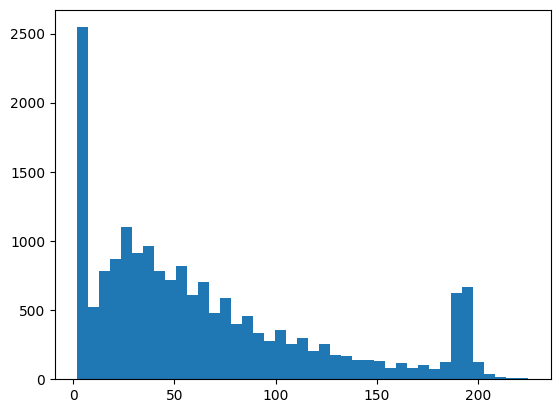

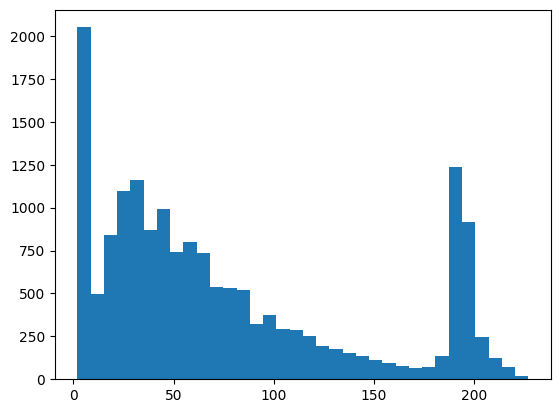

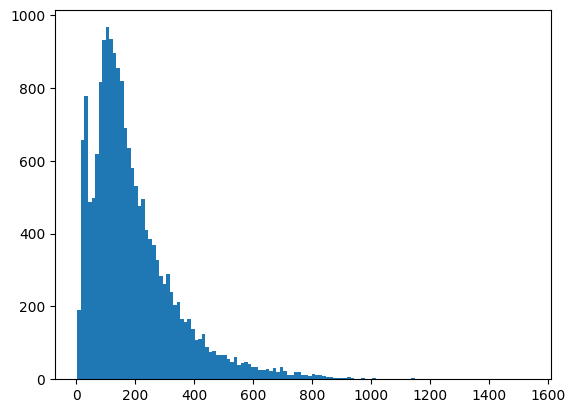

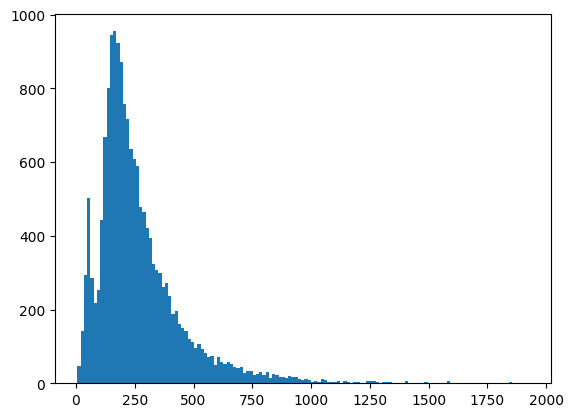

In [69]:
plt.hist(ind['height'], bins='auto'); plt.show()
plt.hist(coll['height'], bins='auto'); plt.show()
plt.hist(ind['width'], bins='auto'); plt.show()
plt.hist(coll['width'], bins='auto'); plt.show()

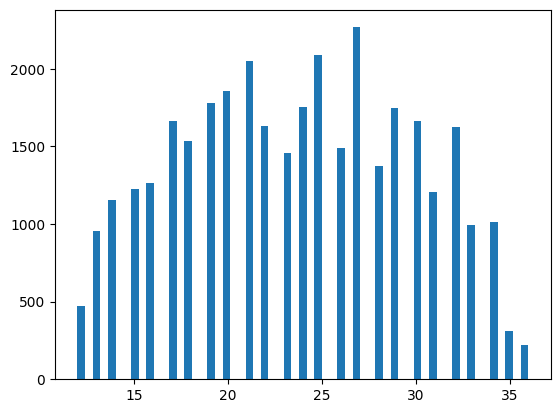

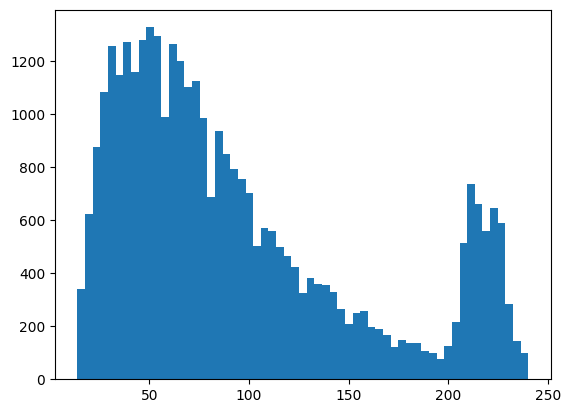

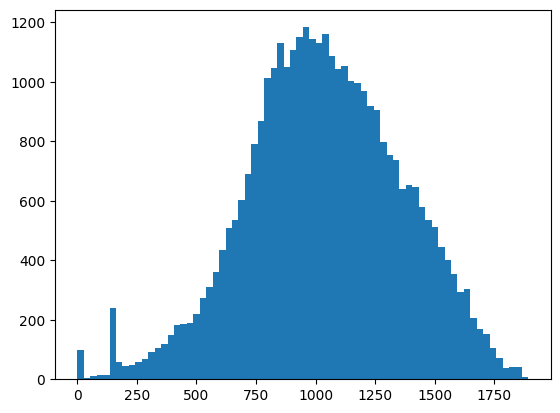

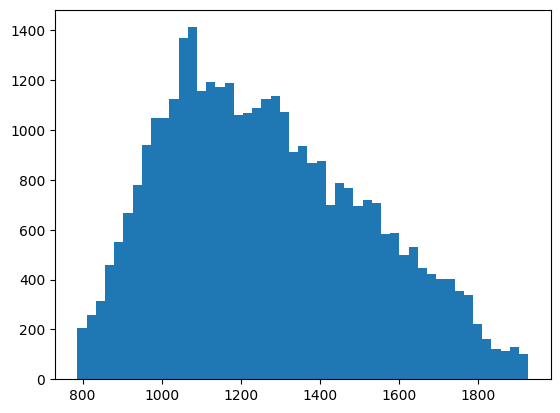

In [70]:
plt.hist(allclusters['bbox_min_row'], bins=59); plt.show()
plt.hist(allclusters['bbox_max_row'], bins=59); plt.show()
plt.hist(allclusters['bbox_min_col'], bins='auto'); plt.show()
plt.hist(allclusters['bbox_max_col'], bins='auto'); plt.show()

In [71]:
def _plane_masks(df):
    pl = df['plane'].str.lower()
    induction_mask = pl.str.contains('induction')
    collection_mask = pl.str.contains('collection')
    return induction_mask, collection_mask

def pair_clusters(df,
                  col_delta_lo=0, col_delta_hi=125, # time difference
                  row_tol=20,                       # wire difference
                  height_tol=5,
                  one_to_one=False):
    """
    Pair clusters across planes per event where:
      - same (run, subrun, event)
      - collection bbox_min/max_col are 0–125 greater than induction’s
      - bbox rows within ±20
      - |height_collection - height_induction| ≤ height_tol (default 5)
    """
    keys = ['run', 'subrun', 'event']
    
    # checks
    for k in keys:
        if k not in df.columns:
            raise ValueError(f"Missing required key column: {k}")

    req = ['bbox_min_row','bbox_max_row','bbox_min_col','bbox_max_col',
           'cluster_idx','plane','height']
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # masks: getting induction and collection plane data
    ind_mask, col_mask = _plane_masks(df)
    ind = df.loc[ind_mask, keys + ['cluster_idx','bbox_min_row','bbox_max_row',
                                   'bbox_min_col','bbox_max_col','height']].copy()
    col = df.loc[col_mask, keys + ['cluster_idx','bbox_min_row','bbox_max_row',
                                   'bbox_min_col','bbox_max_col','height']].copy()

    ind = ind.rename(columns={
        'cluster_idx':'cluster_idx_ind',
        'bbox_min_row':'ind_min_r','bbox_max_row':'ind_max_r',
        'bbox_min_col':'ind_min_c','bbox_max_col':'ind_max_c',
        'height':'ind_h'
    })
    col = col.rename(columns={
        'cluster_idx':'cluster_idx_col',
        'bbox_min_row':'col_min_r','bbox_max_row':'col_max_r',
        'bbox_min_col':'col_min_c','bbox_max_col':'col_max_c',
        'height':'col_h'
    })

    pairs = ind.merge(col, on=keys, how='inner')

    # Deltas
    pairs['d_min_c'] = pairs['col_min_c'] - pairs['ind_min_c'] # time diff
    pairs['d_max_c'] = pairs['col_max_c'] - pairs['ind_max_c']
    pairs['d_min_r'] = pairs['col_min_r'] - pairs['ind_min_r'] # wire diff
    pairs['d_max_r'] = pairs['col_max_r'] - pairs['ind_max_r']
    pairs['d_h']     = pairs['col_h']     - pairs['ind_h']     # height diff

    # rules
    cond = (
        (pairs['d_min_c'].between(col_delta_lo, col_delta_hi)) &
        (pairs['d_max_c'].between(col_delta_lo, col_delta_hi)) &
        (pairs['d_min_r'].abs() <= row_tol) &
        (pairs['d_max_r'].abs() <= row_tol) &
        pairs['ind_h'].notna() & pairs['col_h'].notna() &
        (pairs['d_h'].abs() <= height_tol)
    )

    candidates = pairs.loc[cond].copy()

    # Score: closeness to target column shift + row agreement + height agreement
    target_mid = (col_delta_lo + col_delta_hi) / 2.0
    col_score = (candidates[['d_min_c','d_max_c']] - target_mid).pow(2).sum(axis=1)
    row_score = candidates[['d_min_r','d_max_r']].pow(2).sum(axis=1)
    h_score   = candidates['d_h'].pow(2)
    candidates['match_score'] = (col_score + row_score + h_score).astype(float)

    candidates = candidates.sort_values(keys + ['match_score',
                                                'cluster_idx_ind','cluster_idx_col']).reset_index(drop=True)

    base_cols = keys + [
        'cluster_idx_ind','cluster_idx_col',
        'ind_min_r','ind_max_r','ind_min_c','ind_max_c','ind_h',
        'col_min_r','col_max_r','col_min_c','col_max_c','col_h',
        'd_min_c','d_max_c','d_min_r','d_max_r','d_h','match_score'
    ]

    if not one_to_one:
        return candidates[base_cols]

    # Greedy 1-1 per event
    def _greedy_one_to_one(group):
        g = group.sort_values('match_score').copy()
        used_ind, used_col, keep = set(), set(), []
        for _, row in g.iterrows():
            i, c = row['cluster_idx_ind'], row['cluster_idx_col']
            if i not in used_ind and c not in used_col:
                keep.append(True); used_ind.add(i); used_col.add(c)
            else:
                keep.append(False)
        return g.loc[keep]

    one2one = (
        candidates
        .groupby(keys, group_keys=False)
        .apply(_greedy_one_to_one)
        .reset_index(drop=True)
    )

    return one2one[keys + [
        'cluster_idx_ind','cluster_idx_col',
        'd_min_c','d_max_c','d_min_r','d_max_r','d_h','match_score'
    ]]

# Example:
pairs_1to1 = pair_clusters(allclusters, one_to_one=True, height_tol=5)


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_29622/2815712317.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_greedy_one_to_one)


In [72]:
allclusters.columns

Index(['event_idx', 'run', 'subrun', 'event', 'file_path', 'event_index',
       'particle_type', 'plane', 'cluster_idx', 'area', 'max_intensity',
       'min_intensity', 'mean_intensity', 'total_intensity', 'centroid_x',
       'centroid_y', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row',
       'bbox_max_col', 'width', 'height', 'aspect_ratio', 'compactness',
       'image_intensity', 'matrix_transformed', 'column_maxes'],
      dtype='object')

In [73]:
pairs_1to1

,run,subrun,event,cluster_idx_ind,cluster_idx_col,d_min_c,d_max_c,d_min_r,d_max_r,d_h,match_score
0,8557,4,473,0,0,41,68,12,15,3,870.5
1,8557,7,596,0,0,37,65,17,16,-1,1202.5
2,8557,8,653,0,8,18,71,5,9,4,2174.5
3,8557,9,700,0,0,25,61,6,3,-3,1462.5
4,8557,10,734,0,0,31,69,2,6,4,1090.5
...,...,...,...,...,...,...,...,...,...,...,...
9194,9788,305,26707,0,1,13,81,19,19,0,3514.5
9195,9788,308,26943,0,0,15,55,7,5,-2,2390.5
9196,9788,311,27203,1,2,29,49,6,7,1,1390.5
9197,9788,311,27203,4,0,13,67,-10,-10,0,2670.5


In [74]:
# Run pairing first
pairs_1to1 = pair_clusters(allclusters, one_to_one=True, height_tol=5)

# Extract the induction and collection plane masks
ind_mask, col_mask = _plane_masks(allclusters)
ind_all = allclusters.loc[ind_mask].copy()
col_all = allclusters.loc[col_mask].copy()

# Merge each side carefully using run/subrun/event + index + plane type
induction_df = pairs_1to1.merge(
    ind_all,
    left_on=['run', 'subrun', 'event', 'cluster_idx_ind'],
    right_on=['run', 'subrun', 'event', 'cluster_idx'],
    how='left',
    suffixes=('', '_ind')
)

collection_df = pairs_1to1.merge(
    col_all,
    left_on=['run', 'subrun', 'event', 'cluster_idx_col'],
    right_on=['run', 'subrun', 'event', 'cluster_idx'],
    how='left',
    suffixes=('', '_col')
)


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_29622/2815712317.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_greedy_one_to_one)


In [75]:
collection_df.to_pickle('/Users/user/data/research/proton-deuteron/col&ind/col.pkl')
induction_df.to_pickle('/Users/user/data/research/proton-deuteron/col&ind/ind.pkl')

In [76]:
induction_df.shape,collection_df.shape

((9199, 35), (9199, 35))

In [77]:
collection_df[(collection_df['particle_type'] == 'deuteron')]

,run,subrun,event,cluster_idx_ind,cluster_idx_col,d_min_c,d_max_c,d_min_r,d_max_r,d_h,...,bbox_min_col,bbox_max_row,bbox_max_col,width,height,aspect_ratio,compactness,image_intensity,matrix_transformed,column_maxes
0,8557,4,473,0,0,41,68,12,15,3,...,1419,37,1585,166,8,20.750000,0.463102,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, -0.0, -0.0, 0.0, -0.0, -0.0, 16.0, 0.0]...","[23.0, 158.0, 295.0, 410.0, 353.0, 403.0, 411...."
2,8557,8,653,0,8,18,71,5,9,4,...,1450,221,1621,171,194,0.881443,0.321246,"[[-0.0, -0.0, -0.0, -0.0, -0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 0.0, ...","[43.0, 117.0, 90.0, 83.0, 69.0, 127.0, 150.0, ..."
18,8557,90,4333,0,0,30,65,-4,0,4,...,934,73,1214,280,52,5.384615,0.236745,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0....","[22.0, 78.0, 104.0, 175.0, 171.0, 156.0, 168.0..."
21,8557,97,4665,0,1,27,76,16,13,-3,...,600,122,960,360,90,4.000000,0.182253,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0...","[192.0, 162.0, 150.0, 158.0, 187.0, 204.0, 178..."
23,8557,106,5050,2,1,13,80,8,8,0,...,1158,220,1353,195,192,1.015625,0.249760,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, 0.0, -0.0, -0.0, 0.0, -0.0, 0.0, -0.0,...","[20.0, 72.0, 80.0, 74.0, 77.0, 73.0, 97.0, 79...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9187,9788,268,23513,5,0,11,105,-7,-11,-4,...,942,100,1293,351,81,4.333333,0.163097,"[[0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0....","[[16.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0...","[54.0, 83.0, 117.0, 77.0, 107.0, 67.0, 73.0, 8..."
9189,9788,279,24509,3,0,10,54,6,2,-4,...,1195,128,1436,241,102,2.362745,0.215117,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, 0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0,...","[21.0, 62.0, 66.0, 70.0, 63.0, 61.0, 69.0, 84...."
9192,9788,299,26200,0,1,10,59,0,-1,-1,...,1156,47,1247,91,24,3.791667,0.628205,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0...","[33.0, 121.0, 142.0, 126.0, 123.0, 148.0, 135...."
9196,9788,311,27203,1,2,29,49,6,7,1,...,1628,222,1817,189,196,0.964286,0.247678,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, 0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0,...","[24.0, 49.0, 55.0, 61.0, 66.0, 56.0, 56.0, 62...."


In [78]:
col = collection_df['image_intensity'].values
ind = induction_df['image_intensity'].values

/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_29622/2815712317.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_greedy_one_to_one)


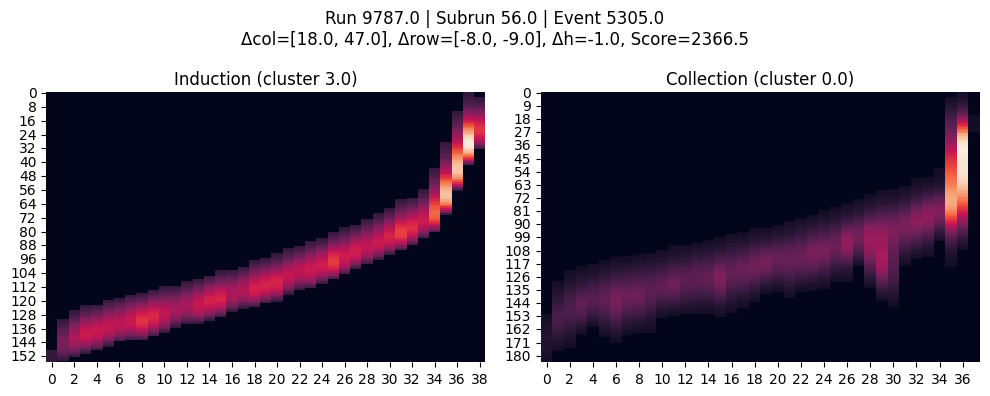

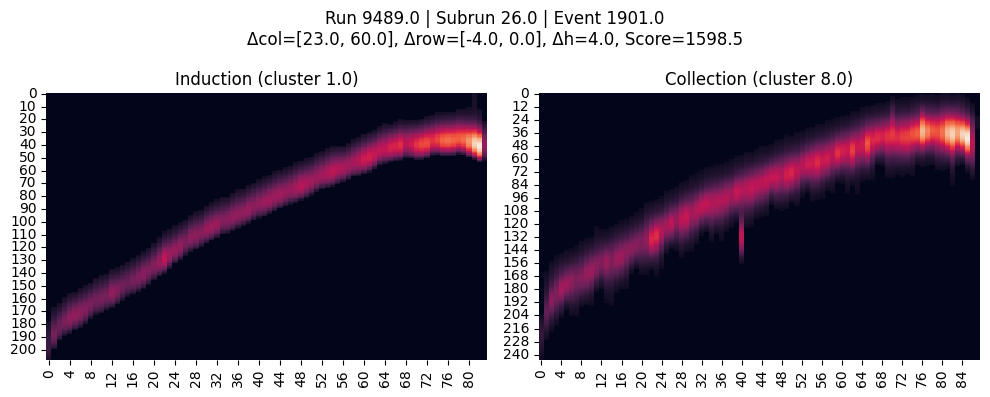

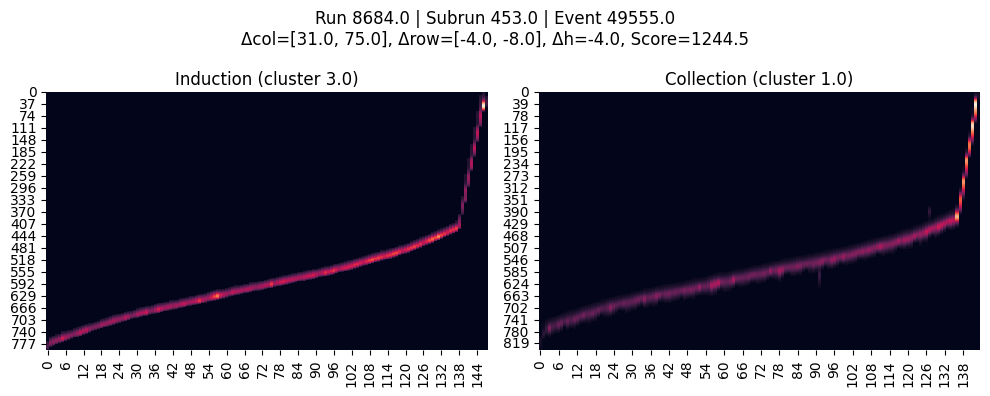

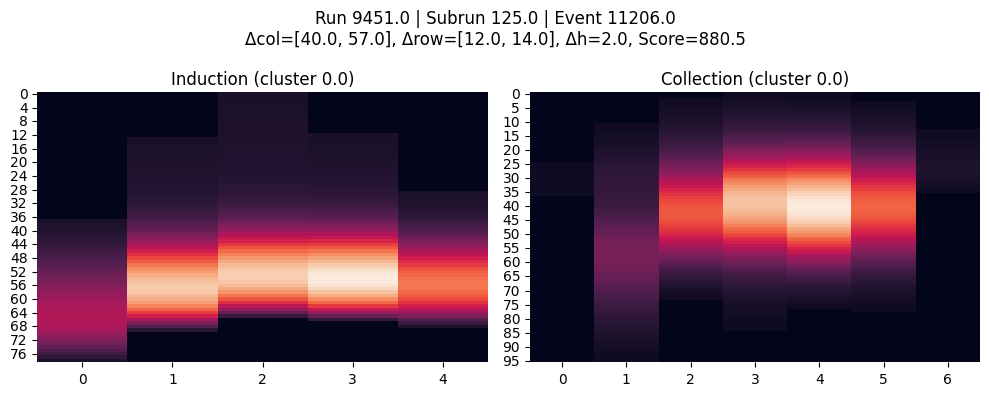

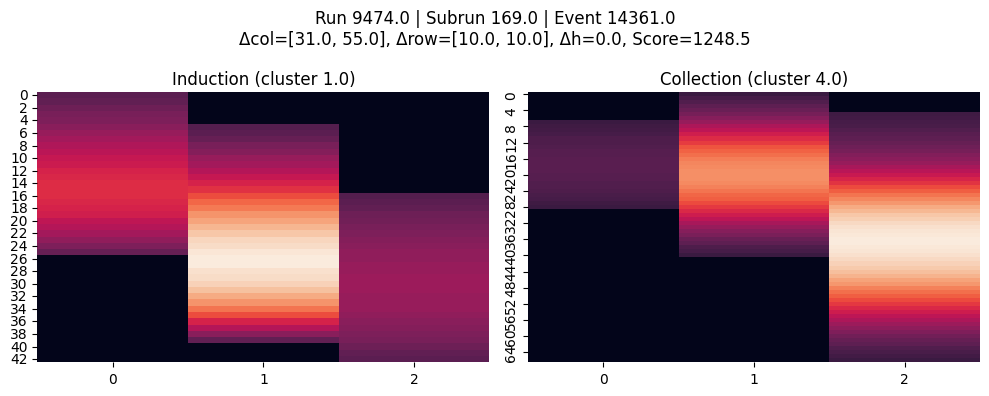

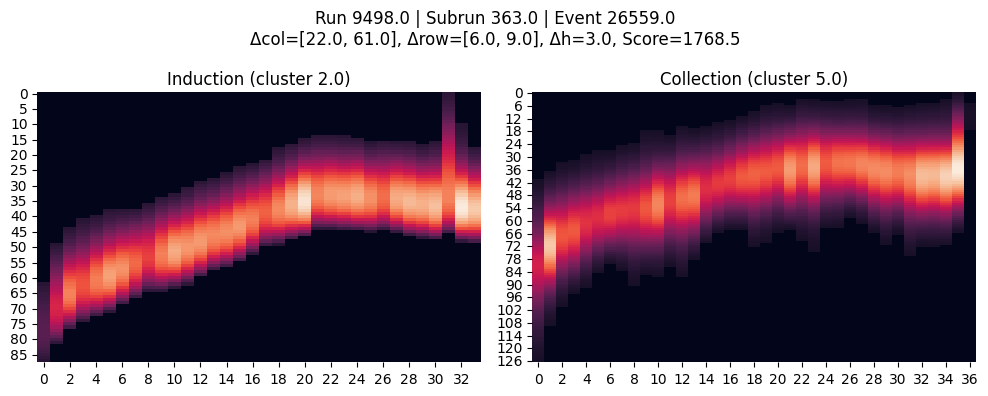

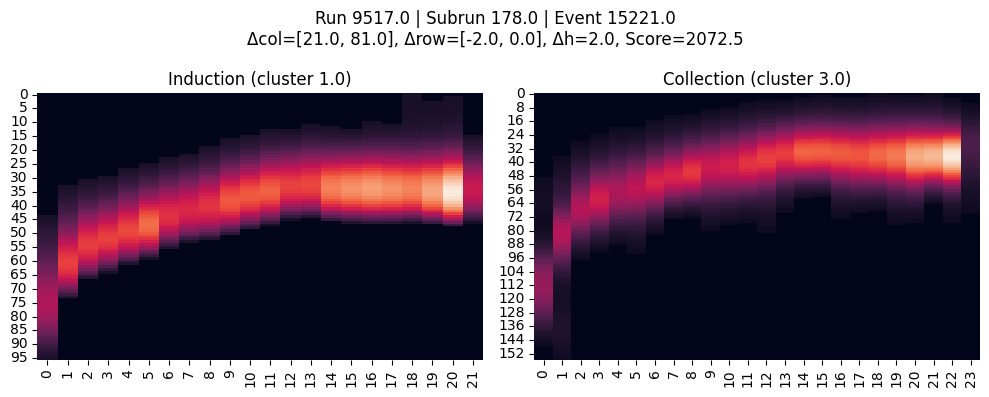

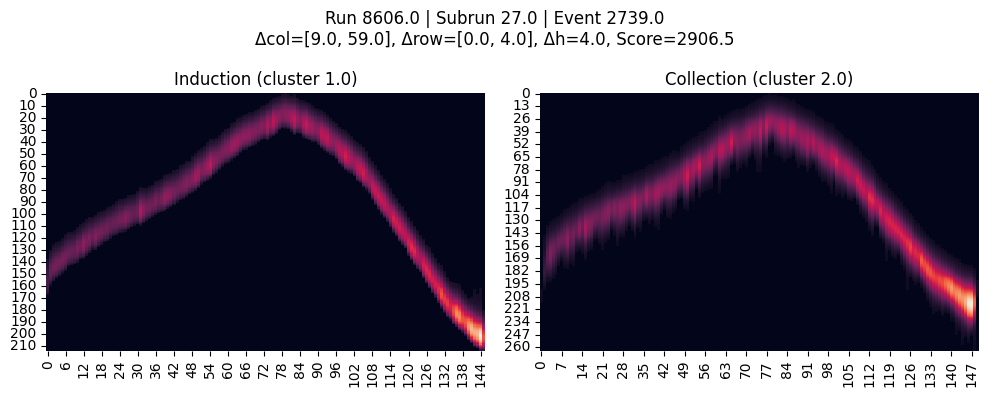

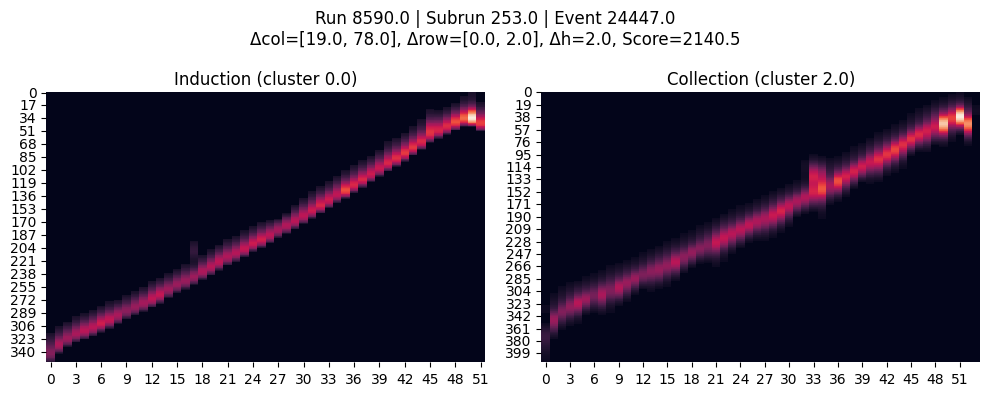

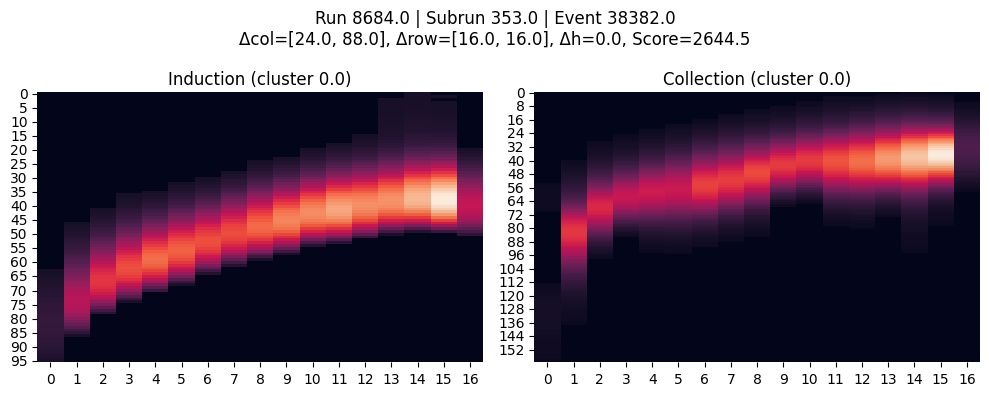

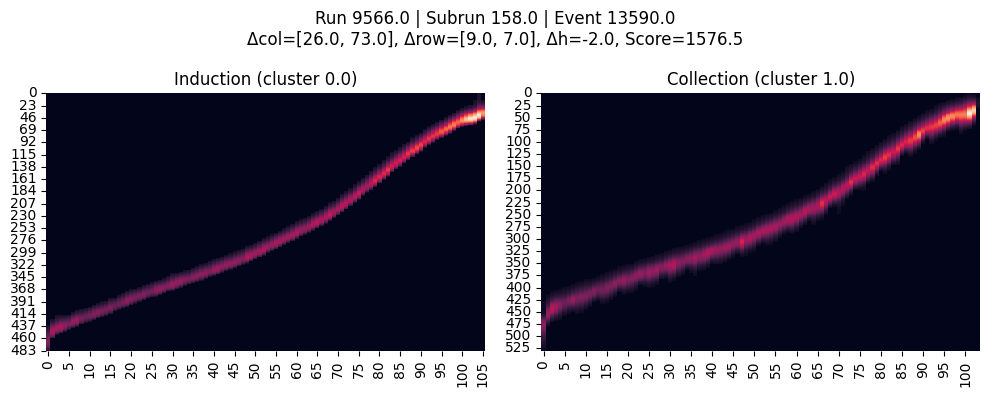

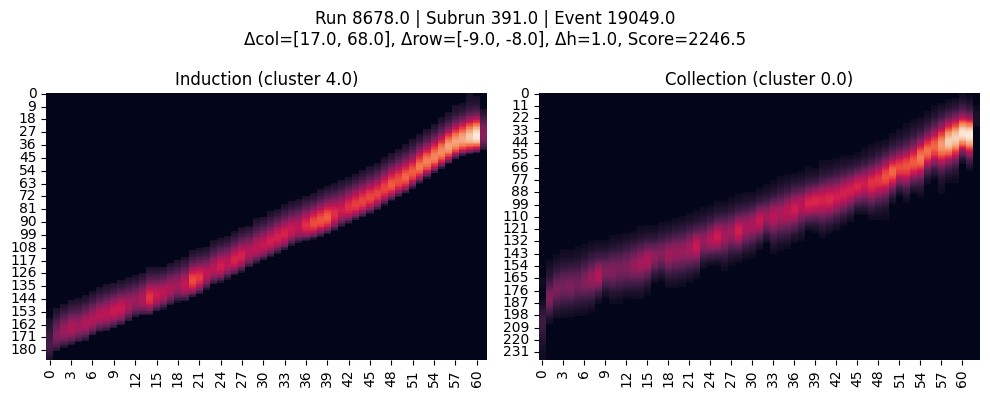

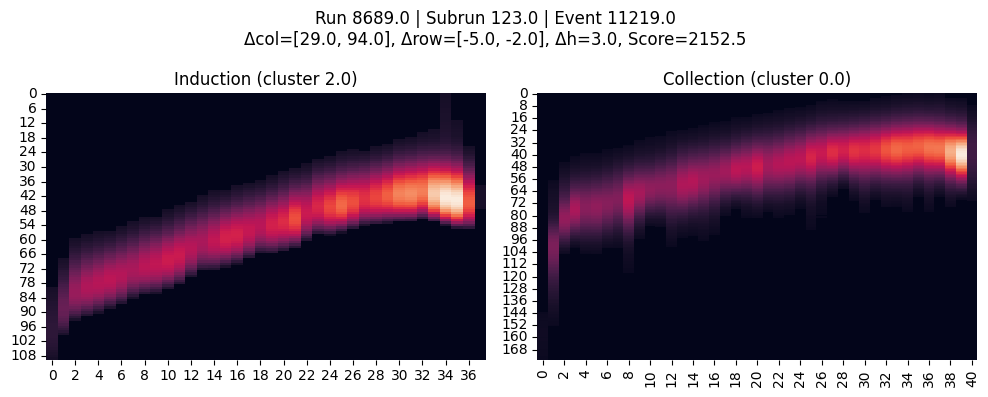

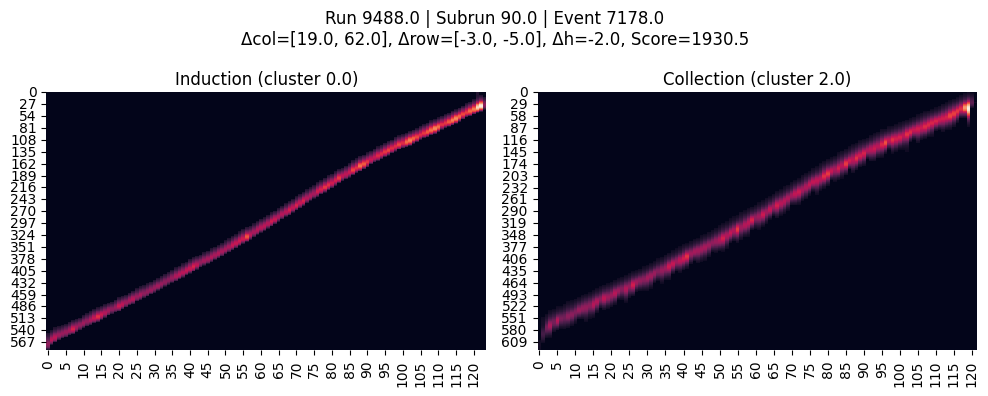

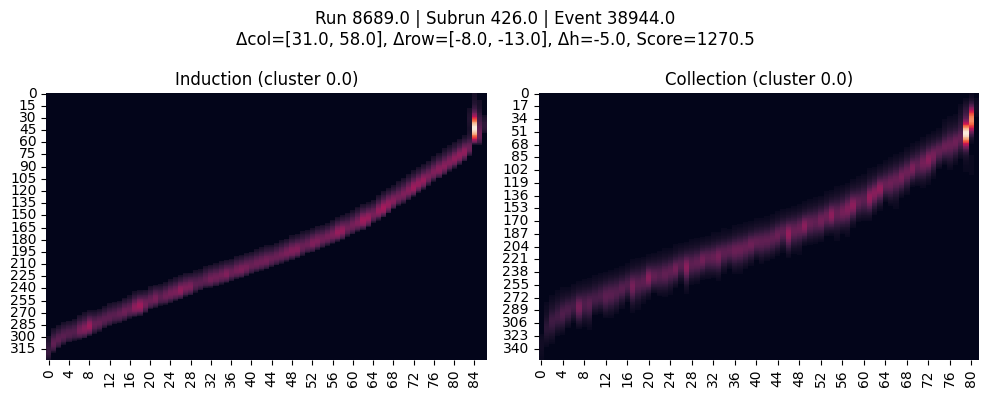

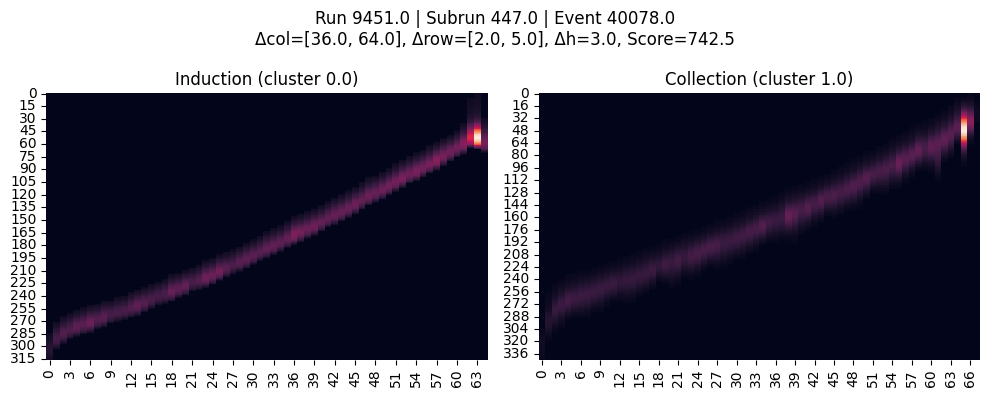

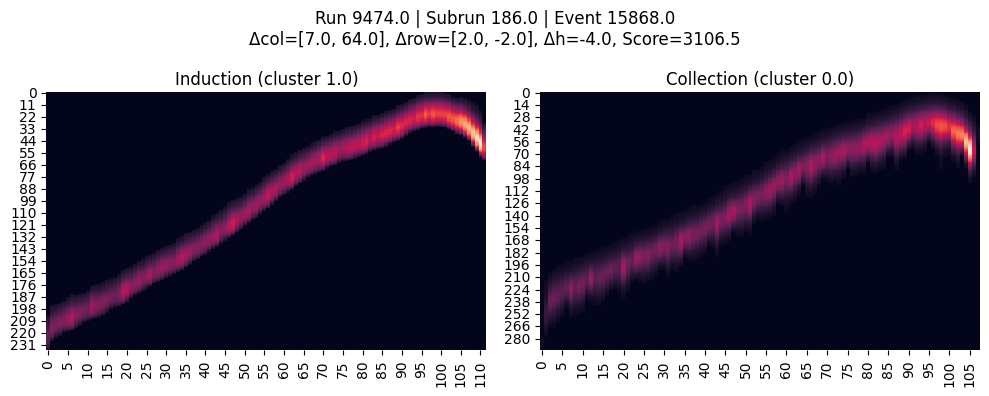

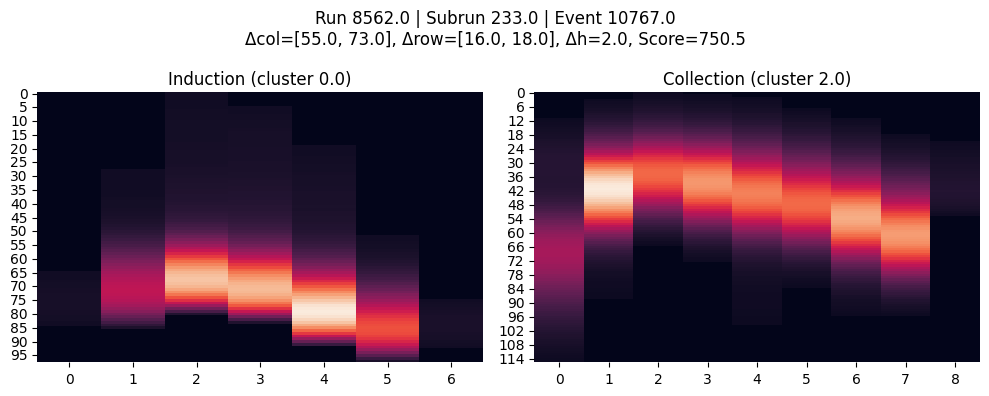

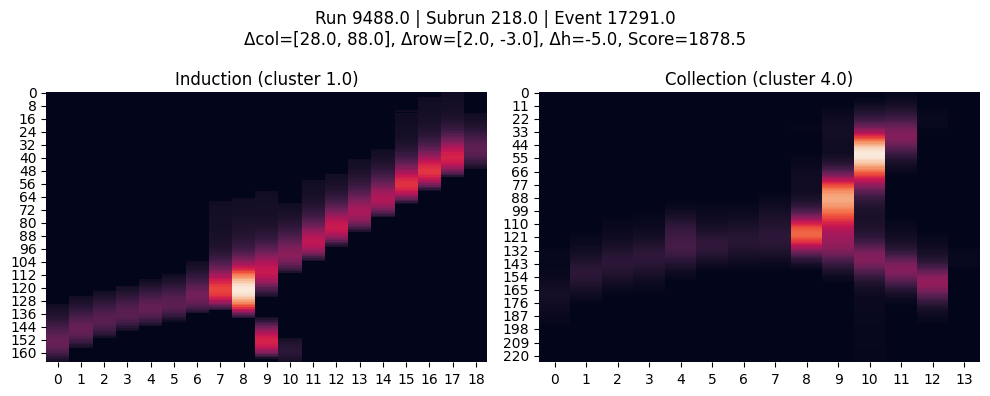

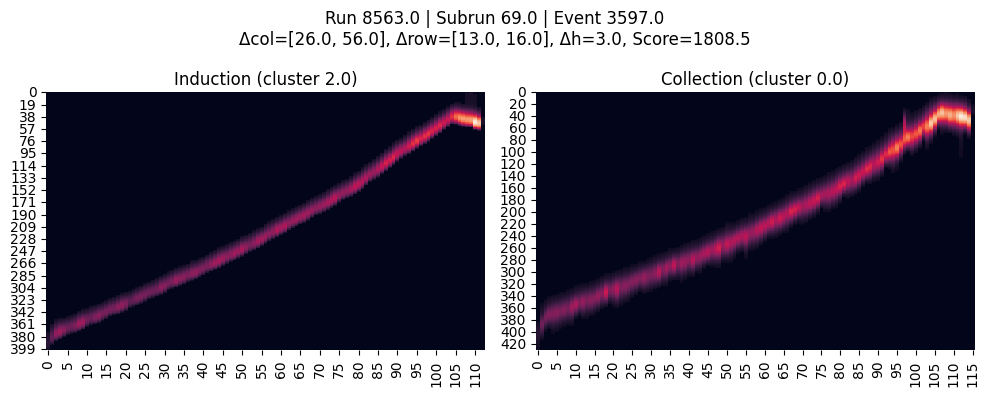

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_random_cluster_pairs(df, pairs, n_samples=5, random_state=None):
    """
    Randomly pick matched cluster pairs and plot induction vs collection side by side.
    
    df: full cluster DataFrame (with 'image_intensity' & 'plane')
    pairs: output of pair_clusters()
    n_samples: number of random pairs to plot
    random_state: set for reproducibility
    """
    if len(pairs) == 0:
        print("No pairs to plot.")
        return
    
    sample_pairs = pairs.sample(n=min(n_samples, len(pairs)), 
                                random_state=random_state)
    
    for _, pair in sample_pairs.iterrows():
        # Select the corresponding clusters
        ind = df[(df['plane'] == 'induction') &
                 (df['cluster_idx'] == pair['cluster_idx_ind']) &
                 (df['event'] == pair['event']) &
                 (df['subrun'] == pair['subrun']) &
                 (df['run'] == pair['run'])]
        col = df[(df['plane'] == 'collection') & 
                 (df['cluster_idx'] == pair['cluster_idx_col']) &
                 (df['event'] == pair['event']) &
                 (df['subrun'] == pair['subrun']) &
                 (df['run'] == pair['run'])]

        if ind.empty or col.empty:
            continue
        
        ind_row = ind.iloc[0]
        col_row = col.iloc[0]

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        
        sns.heatmap(ind_row['image_intensity'].T, ax=axes[0], cbar=False)
        axes[0].set_title(f"Induction (cluster {pair['cluster_idx_ind']})")

        sns.heatmap(col_row['image_intensity'].T, ax=axes[1], cbar=False)
        axes[1].set_title(f"Collection (cluster {pair['cluster_idx_col']})")

        fig.suptitle(
            f"Run {pair['run']} | Subrun {pair['subrun']} | Event {pair['event']}\n"
            f"Δcol=[{pair['d_min_c']:.1f}, {pair['d_max_c']:.1f}], "
            f"Δrow=[{pair['d_min_r']:.1f}, {pair['d_max_r']:.1f}], "
            f"Δh={pair.get('d_h', float(col_row['height']-ind_row['height'])):.1f}, "
            f"Score={pair['match_score']:.1f}"
        )
        
        plt.tight_layout()
        plt.show()


d = allclusters[(allclusters['particle_type'] == 'deuteron')]               # & (allclusters['height'] < 17) 
p = allclusters[(allclusters['particle_type'] == 'proton')]
pairs = pair_clusters(d, one_to_one=True)
plot_random_cluster_pairs(d, pairs, n_samples=20, random_state=None)

In [80]:
pairs

,run,subrun,event,cluster_idx_ind,cluster_idx_col,d_min_c,d_max_c,d_min_r,d_max_r,d_h,match_score
0,8557,4,473,0,0,41,68,12,15,3,870.5
1,8557,8,653,0,8,18,71,5,9,4,2174.5
2,8557,90,4333,0,0,30,65,-4,0,4,1094.5
3,8557,97,4665,0,1,27,76,16,13,-3,1876.5
4,8557,106,5050,2,1,13,80,8,8,0,2884.5
...,...,...,...,...,...,...,...,...,...,...,...
3624,9788,268,23513,5,0,11,105,-7,-11,-4,4644.5
3625,9788,279,24509,3,0,10,54,6,2,-4,2884.5
3626,9788,299,26200,0,1,10,59,0,-1,-1,2770.5
3627,9788,311,27203,1,2,29,49,6,7,1,1390.5
